# Econometrics I

```
TA Christian Alemán
```

**Session 8: Monday 14, March 2022**

**1: Measurement Error**

1. Measurement error in the dependent variable
2. Measurement error in the independent variable
3. IV Estimation

**The case with no measurement error**

Consider the following DGP:

$$y^{*} = \beta_{0} +\beta_{1}x^{*} +e$$

$$e\sim N(0,2)$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def ols(y, x):
    '''
    Simple OLS regression
    '''
    t = x.shape[0]
    beta = np.linalg.inv(x.T @ x) @ (x.T @ y)
    sigma = (y - x @ beta) @ (y - x @ beta) / (t - np.linalg.matrix_rank(x))
    r = y - x @ beta
    return beta, sigma, r


def eemult_mv(m, v):
    if m.ndim != 2:
        raise ValueError('eemult_mv: first arg must be a matrix')
    v = np.asarray(v)
    if v.ndim != 1:
        raise ValueError('eemult_mv: second arg must be a vector')
    rm, cm = m.shape
    rv = v.shape[0]
    if rm == rv:
        result = m * v[:, None]
    elif cm == rv:
        result = m * v[None, :]
    else:
        raise ValueError('eemult_mv: dimension of vector must match one of the dimensions of the matrix')
    return result


def prettyprint(mat, rlabels, clabels):
    '''
    This function prints matrices with row and column labels

    Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation
    '''
    header = ''.join(f'{c:>10}  ' for c in clabels)
    print('   ' + header)
    for i in range(mat.shape[0]):
        row_vals = ''.join(f'{v:10.3f}' for v in mat[i, :])
        print(f'{str(rlabels[i]):<10}{row_vals}')


def mc_ols(y, x, names=None, silent=False, regularvc=False):
    '''
    Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation

    Calculates ordinary LS estimator using the Huber-White heteroscedastic
    consistent variance estimator.

    inputs:
    y: dep variable
    x: matrix of regressors
    names (optional) names of regressors
    silent (bool) default false. controls screen output
    regularvc (bool) default false. use normal varcov estimator, instead of het consistent (default)

    outputs:
    b: estimated coefficients
    varb: estimated covariance matrix of coefficients (Huber-White by default, ordinary OLS if requested with switch)
    e: ols residuals
    ess: sum of squared residuals
    '''
    k = x.shape[1]
    if names is None or len(names) != k:
        names = [str(i + 1) for i in range(k)]

    b, sigsq, e = ols(y, x)
    xx_inv = np.linalg.inv(x.T @ x)
    n = x.shape[0]
    ess = e @ e

    # Ordinary or het. consistent variance estimate
    if regularvc:
        varb = xx_inv * sigsq

    seb = np.sqrt(np.diag(varb))
    t = b / seb

    tss = y - y.mean()
    tss = tss @ tss
    rsq = 1 - ess / tss

    labels = ['estimate', 'st.err.', 't-stat.', 'p-value']
    if not silent:
        print('\n*********************************************************')
        print('OLS estimation results')
        print(f'Observations {n}')
        print(f'R-squared {rsq:.6f}')
        print(f'Sigma-squared {sigsq:.6f}')
        p = 2 - 2 * stats.t.cdf(np.abs(t), n - k)
        results = np.column_stack([b, seb, t, p])
        if regularvc:
            print('\nResults (Ordinary var-cov estimator)\n')
        else:
            print('\nResults (Het. consistent var-cov estimator)\n')
        prettyprint(results, names, labels)
        print('\n*********************************************************')

    return b, varb, e, ess


def mc_olsIV(y, x, z, names=None, silent=False, regularvc=False):
    '''
    Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation

    Calculates ordinary LS estimator using the Huber-White heteroscedastic
    consistent variance estimator.

    inputs:
    y: dep variable
    x: matrix of regressors
    names (optional) names of regressors
    silent (bool) default false. controls screen output
    regularvc (bool) default false. use normal varcov estimator, instead of het consistent (default)

    outputs:
    b: estimated coefficients
    varb: estimated covariance matrix of coefficients (Huber-White by default, ordinary OLS if requested with switch)
    e: ols residuals
    ess: sum of squared residuals
    '''
    k = x.shape[1]
    if names is None or len(names) != k:
        names = [str(i + 1) for i in range(k)]

    t = x.shape[0]
    b = np.linalg.inv(z.T @ x) @ (z.T @ y)
    sigsq = (y - x @ b) @ (y - x @ b) / (t - np.linalg.matrix_rank(x))
    e = y - x @ b

    xx_inv = np.linalg.inv(z.T @ x)
    n = x.shape[0]
    ess = e @ e

    if regularvc:
        varb = xx_inv * sigsq

    seb = np.sqrt(np.diag(varb))
    tstat = b / seb

    tss = y - y.mean()
    tss = tss @ tss
    rsq = 1 - ess / tss

    labels = ['estimate', 'st.err.', 't-stat.', 'p-value']
    if not silent:
        print('\n*********************************************************')
        print('OLS estimation results')
        print(f'Observations {n}')
        print(f'R-squared {rsq:.6f}')
        print(f'Sigma-squared {sigsq:.6f}')
        p = 2 - 2 * stats.t.cdf(np.abs(tstat), n - k)
        results = np.column_stack([b, seb, tstat, p])
        if regularvc:
            print('\nResults (Ordinary var-cov estimator)\n')
        else:
            print('\nResults (Het. consistent var-cov estimator)\n')
        prettyprint(results, names, labels)
        print('\n*********************************************************')

    return b, varb, e, ess



*********************************************************
OLS estimation results
Observations 1000
R-squared 0.895838
Sigma-squared 2.021068

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       1.848     0.222     8.314     0.000
beta_{1}       2.018     0.022    92.646     0.000

*********************************************************


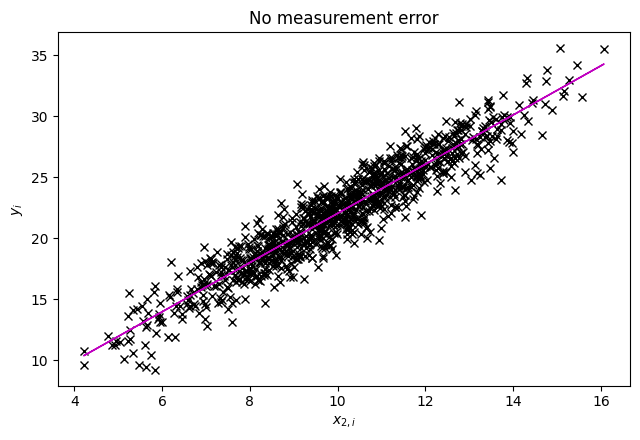

In [2]:
rng = np.random.default_rng(123)

N = 1000
betas = np.array([2.0, 2.0])
err = np.sqrt(2) * rng.standard_normal(N)
x2_star = 10 + 2 * rng.standard_normal(N)
X_star = np.column_stack([np.ones(N), x2_star])
y_star = X_star @ betas + err


def ols_func(X, y):
    return np.linalg.inv(X.T @ X) @ (X.T @ y)


# The OLS estimation of the true model is
names = ['beta_{0}', 'beta_{1}']

b, varb, e, ess = mc_ols(y_star, X_star, names, False, True)
y_pred = X_star @ b

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(x2_star, y_star, 'kx', markerfacecolor='k')
ax.plot(x2_star, y_pred, 'm-', linewidth=1.1)
ax.set_ylabel('$y_{i}$')
ax.set_xlabel('$x_{2,i}$')
ax.set_title('No measurement error')
plt.tight_layout()
plt.show()


**1.1: Measurement error in the dependent variable**

$$y = y^{*}+\nu$$

In this case OLS is still unbiased and consistent.


*********************************************************
OLS estimation results
Observations 1000
R-squared 0.745056
Sigma-squared 5.736559

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       2.172     0.374     5.801     0.000
beta_{1}       1.982     0.037    54.005     0.000

*********************************************************


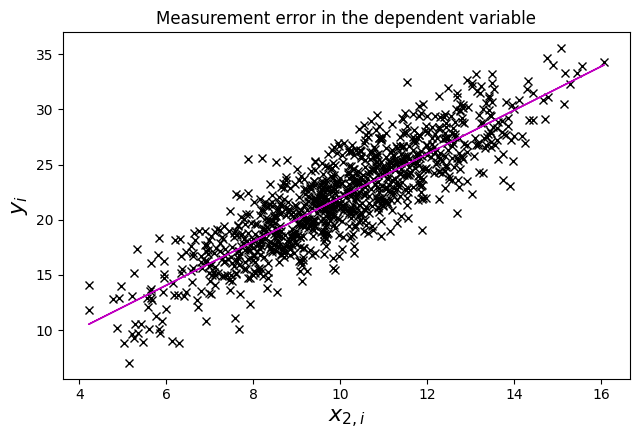

In [3]:
v = 2 * rng.standard_normal(N)
y = y_star + v

# OLS estimation
b, varb, e, ess = mc_ols(y, X_star, names, False, True)
y_pred = X_star @ b

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(x2_star, y, 'kx', markerfacecolor='k')
ax.plot(x2_star, y_pred, 'm-', linewidth=1.1)
ax.set_ylabel('$y_{i}$', fontsize=16)
ax.set_xlabel('$x_{2,i}$', fontsize=16)
ax.set_title('Measurement error in the dependent variable')
plt.tight_layout()
plt.show()


See that with a Montecarlo experiment:

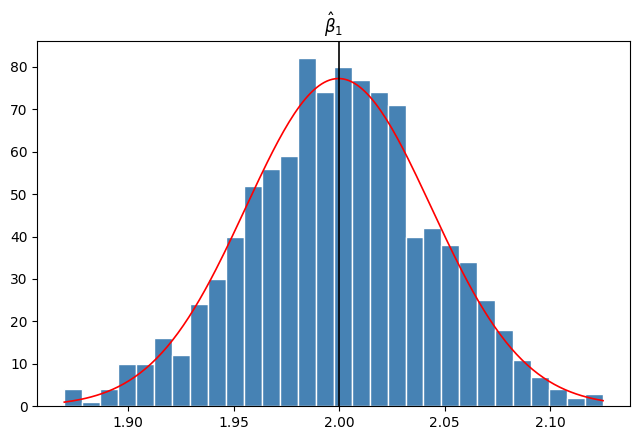

In [4]:
no_reps = 1000
K = X_star.shape[1]
MC_betas = np.full((no_reps, K), np.nan)

for i in range(no_reps):
    e_rep = np.sqrt(4) * rng.standard_normal(N)   # The error term of the regression
    y_star_rep = X_star @ betas + e_rep
    v = 2 * rng.standard_normal(N)
    y_rep = y_star_rep + v
    MC_betas[i, :] = ols_func(X_star, y_rep)

data = MC_betas[:, 1]
mu_hat, sigma_hat = data.mean(), data.std(ddof=1)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
counts, bin_edges, _ = ax.hist(data, bins=30, color='steelblue', edgecolor='white')
support = np.linspace(bin_edges[0], bin_edges[-1], 200)
bin_width = bin_edges[1] - bin_edges[0]
ax.plot(support, stats.norm.pdf(support, mu_hat, sigma_hat) * no_reps * bin_width, 'r-', linewidth=1.2)
ax.axvline(mu_hat, color='k', linewidth=1.2)
ax.set_title(r'$\hat{\beta}_{1}$')
plt.tight_layout()
plt.show()


**1.2: Measurement error in the explanatory variable: Attenuation bias**

$$x = x^{*}+\nu$$

Under attenuation bias the OLS estimator will be biased towards 0.


*********************************************************
OLS estimation results
Observations 1000
R-squared 0.063730
Sigma-squared 18.166513

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}      20.640     0.214    96.405     0.000
beta_{1}       0.134     0.016     8.242     0.000

*********************************************************


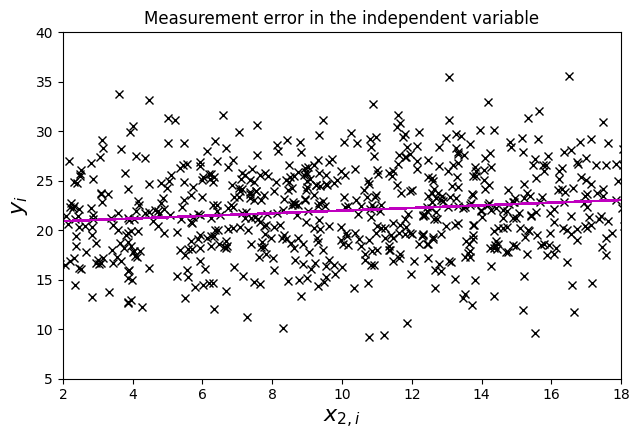

In [5]:
# Now suppose our independent variable is measured with error
v = 8 * rng.standard_normal(N)
x2 = x2_star + v

X = np.column_stack([np.ones(N), x2])

# OLS estimation
b, varb, e, ess = mc_ols(y_star, X, names, False, True)
y_pred = X @ b

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(x2, y_star, 'kx', markerfacecolor='k')
ax.plot(x2, y_pred, 'm-', linewidth=1.2)
ax.set_ylabel('$y_{i}$', fontsize=16)
ax.set_xlabel('$x_{2,i}$', fontsize=16)
ax.set_xlim(2, 18)
ax.set_ylim(5, 40)
ax.set_title('Measurement error in the independent variable')
plt.tight_layout()
plt.show()


See that with a Montecarlo experiment:

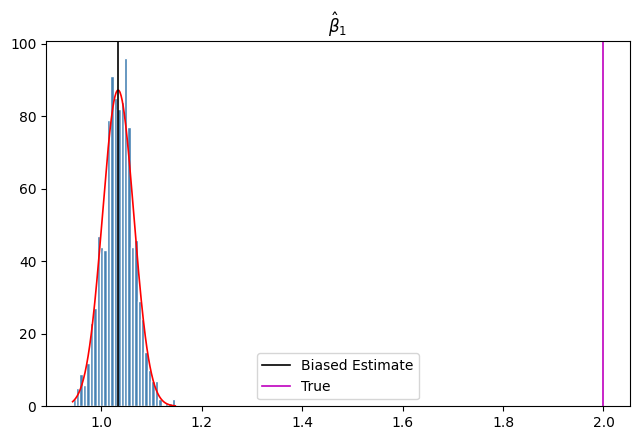

In [6]:
K = X.shape[1]
MC_betas = np.full((no_reps, K), np.nan)

for i in range(no_reps):
    e_rep = np.sqrt(4) * rng.standard_normal(N)   # The error term of the regression
    y_star_rep = X_star @ betas + e_rep
    v = 2 * rng.standard_normal(N)
    x2 = x2_star + v          # Classical additive measurement error
    X = np.column_stack([np.ones(N), x2])
    MC_betas[i, :] = ols_func(X, y_star_rep)

data = MC_betas[:, 1]
mu_hat, sigma_hat = data.mean(), data.std(ddof=1)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
counts, bin_edges, _ = ax.hist(data, bins=30, color='steelblue', edgecolor='white')
support = np.linspace(bin_edges[0], bin_edges[-1], 200)
bin_width = bin_edges[1] - bin_edges[0]
ax.plot(support, stats.norm.pdf(support, mu_hat, sigma_hat) * no_reps * bin_width, 'r-', linewidth=1.2)
p1 = ax.axvline(mu_hat, color='k', linewidth=1.2, label='Biased Estimate')
p2 = ax.axvline(2, color='m', linewidth=1.2, label='True')
ax.set_title(r'$\hat{\beta}_{1}$')
ax.legend()
plt.tight_layout()
plt.show()


**Dealing with measurement error**

1. IV
2. 2SLS

**Example Instrumental Variable Estimation.**

In [7]:
n = 1000

z1 = 3 * rng.standard_normal(n)
z2 = 2 * rng.standard_normal(n)

x = 3 - 2 * z2 + 4 * z1 + rng.standard_normal(n)
y = 2 + 2 * x + 12 * z2 + rng.standard_normal(n)

# Case with no omitted variable

X = np.column_stack([np.ones(n), x, z2])
names = ['beta_{0}', 'beta_{1}', 'beta_{2}']
b, varb, e, ess = mc_ols(y, X, names, False, True)



*********************************************************
OLS estimation results
Observations 1000
R-squared 0.998719
Sigma-squared 1.014289

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       2.054     0.033    62.300     0.000
beta_{1}       1.997     0.003   738.178     0.000
beta_{2}      11.994     0.017   722.037     0.000

*********************************************************


Suppose we only observe x and z1:

Case with omitted variable:

In [8]:
X = np.column_stack([np.ones(n), x])
names = ['beta_{0}', 'beta_{1}']
b, varb, e, ess = mc_ols(y, X, names, False, True)



*********************************************************
OLS estimation results
Observations 1000
R-squared 0.329042
Sigma-squared 530.860253

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       3.842     0.752     5.107     0.000
beta_{1}       1.271     0.057    22.123     0.000

*********************************************************


**Solution**

We can use z1 as an instrument:

1. z1 is correlated with x
2. z1 is not correlated to z2, thus not correlated with the residuals

**Case 1: A very good instrument**

In [9]:
print('Check Correlation between x and z1')
print(np.corrcoef(x, z1)[0, 1])

Z = np.column_stack([np.ones(n), z1])

b, varb, e, ess = mc_olsIV(y, X, Z, names, False, True)
# b_IV = inv(Z'X) @ Z'y


Check Correlation between x and z1
0.9426580653971448

*********************************************************
OLS estimation results
Observations 1000
R-squared 0.250798
Sigma-squared 592.767152

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       1.822     0.771     2.362     0.018
beta_{1}       1.891     0.130    14.565     0.000

*********************************************************


Two Stage Least Squares

In [10]:
b_hat_x = np.linalg.inv(Z.T @ Z) @ (Z.T @ X)
X_hat = Z @ b_hat_x

b, varb, e, ess = mc_ols(y, X_hat, names, False, True)
# b_2SLS = inv(X_hat'X_hat) @ X_hat'y



*********************************************************
OLS estimation results
Observations 1000
R-squared 0.647079
Sigma-squared 279.230631

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       1.822     0.548     3.326     0.001
beta_{1}       1.891     0.044    42.776     0.000

*********************************************************


**Case 2: A good instrument**

In [11]:
z1 = 0.9 * rng.standard_normal(n)
x = 3 - 2 * z2 + 4 * z1 + rng.standard_normal(n)
y = 2 + 2 * x + 12 * z2 + rng.standard_normal(n)

print('Check Correlation between x and z1')
print(np.corrcoef(x, z1)[0, 1])

X = np.column_stack([np.ones(n), x])
Z = np.column_stack([np.ones(n), z1])

b, varb, e, ess = mc_olsIV(y, X, Z, names, False, True)
# b_IV = inv(Z'X) @ Z'y


Check Correlation between x and z1
0.6084730108654998

*********************************************************
OLS estimation results
Observations 1000
R-squared -1.091319
Sigma-squared 704.242852

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       0.135     0.843     0.160     0.873
beta_{1}       2.413     0.488     4.944     0.000

*********************************************************


Two Stage Least Squares

In [12]:
b_hat_x = np.linalg.inv(Z.T @ Z) @ (Z.T @ X)
X_hat = Z @ b_hat_x

b, varb, e, ess = mc_ols(y, X_hat, names, False, True)
# b_2SLS = inv(X_hat'X_hat) @ X_hat'y



*********************************************************
OLS estimation results
Observations 1000
R-squared 0.189611
Sigma-squared 272.895135

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       0.135     0.719     0.188     0.851
beta_{1}       2.413     0.158    15.281     0.000

*********************************************************


**Case 3: A weak instrument**

In [13]:
z1 = 0.07 * rng.standard_normal(n)
x = 3 - 2 * z2 + 4 * z1 + rng.standard_normal(n)
y = 2 + 2 * x + 12 * z2 + rng.standard_normal(n)

print('Check Correlation between x and z1')
print(np.corrcoef(x, z1)[0, 1])

X = np.column_stack([np.ones(n), x])
Z = np.column_stack([np.ones(n), z1])

b, varb, e, ess = mc_olsIV(y, X, Z, names, False, True)
# b_IV = inv(Z'X) @ Z'y


Check Correlation between x and z1
0.07594226702950717

*********************************************************
OLS estimation results
Observations 1000
R-squared -0.882969
Sigma-squared 519.117128

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       2.988     0.723     4.136     0.000
beta_{1}       1.508     4.858     0.311     0.756

*********************************************************


Two Stage Least Squares

In [14]:
b_hat_x = np.linalg.inv(Z.T @ Z) @ (Z.T @ X)
X_hat = Z @ b_hat_x

b, varb, e, ess = mc_ols(y, X_hat, names, False, True)
# b_2SLS = inv(X_hat'X_hat) @ X_hat'y



*********************************************************
OLS estimation results
Observations 1000
R-squared 0.000887
Sigma-squared 275.446118

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
beta_{0}       2.988     5.098     0.586     0.558
beta_{1}       1.508     1.602     0.941     0.347

*********************************************************


This markdown was constructed based on the IPYNB code below.

In [15]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import stats
#
#
# def ols(y, x):
#     '''
#     Simple OLS regression
#     '''
#     t = x.shape[0]
#     beta = np.linalg.inv(x.T @ x) @ (x.T @ y)
#     sigma = (y - x @ beta) @ (y - x @ beta) / (t - np.linalg.matrix_rank(x))
#     r = y - x @ beta
#     return beta, sigma, r
#
#
# def eemult_mv(m, v):
#     if m.ndim != 2:
#         raise ValueError('eemult_mv: first arg must be a matrix')
#     v = np.asarray(v)
#     if v.ndim != 1:
#         raise ValueError('eemult_mv: second arg must be a vector')
#     rm, cm = m.shape
#     rv = v.shape[0]
#     if rm == rv:
#         result = m * v[:, None]
#     elif cm == rv:
#         result = m * v[None, :]
#     else:
#         raise ValueError('eemult_mv: dimension of vector must match one of the dimensions of the matrix')
#     return result
#
#
# def prettyprint(mat, rlabels, clabels):
#     '''
#     This function prints matrices with row and column labels
#
#     Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
#     This program is free software; you can redistribute it and/or modify
#     it under the terms of the GNU General Public License as published by
#     the Free Software Foundation
#     '''
#     header = ''.join(f'{c:>10}  ' for c in clabels)
#     print('   ' + header)
#     for i in range(mat.shape[0]):
#         row_vals = ''.join(f'{v:10.3f}' for v in mat[i, :])
#         print(f'{str(rlabels[i]):<10}{row_vals}')
#
#
# def mc_ols(y, x, names=None, silent=False, regularvc=False):
#     '''
#     Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
#     This program is free software; you can redistribute it and/or modify
#     it under the terms of the GNU General Public License as published by
#     the Free Software Foundation
#
#     Calculates ordinary LS estimator using the Huber-White heteroscedastic
#     consistent variance estimator.
#
#     inputs:
#     y: dep variable
#     x: matrix of regressors
#     names (optional) names of regressors
#     silent (bool) default false. controls screen output
#     regularvc (bool) default false. use normal varcov estimator, instead of het consistent (default)
#
#     outputs:
#     b: estimated coefficients
#     varb: estimated covariance matrix of coefficients (Huber-White by default, ordinary OLS if requested with switch)
#     e: ols residuals
#     ess: sum of squared residuals
#     '''
#     k = x.shape[1]
#     if names is None or len(names) != k:
#         names = [str(i + 1) for i in range(k)]
#
#     b, sigsq, e = ols(y, x)
#     xx_inv = np.linalg.inv(x.T @ x)
#     n = x.shape[0]
#     ess = e @ e
#
#     # Ordinary or het. consistent variance estimate
#     if regularvc:
#         varb = xx_inv * sigsq
#
#     seb = np.sqrt(np.diag(varb))
#     t = b / seb
#
#     tss = y - y.mean()
#     tss = tss @ tss
#     rsq = 1 - ess / tss
#
#     labels = ['estimate', 'st.err.', 't-stat.', 'p-value']
#     if not silent:
#         print('\n*********************************************************')
#         print('OLS estimation results')
#         print(f'Observations {n}')
#         print(f'R-squared {rsq:.6f}')
#         print(f'Sigma-squared {sigsq:.6f}')
#         p = 2 - 2 * stats.t.cdf(np.abs(t), n - k)
#         results = np.column_stack([b, seb, t, p])
#         if regularvc:
#             print('\nResults (Ordinary var-cov estimator)\n')
#         else:
#             print('\nResults (Het. consistent var-cov estimator)\n')
#         prettyprint(results, names, labels)
#         print('\n*********************************************************')
#
#     return b, varb, e, ess
#
#
# def mc_olsIV(y, x, z, names=None, silent=False, regularvc=False):
#     '''
#     Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
#     This program is free software; you can redistribute it and/or modify
#     it under the terms of the GNU General Public License as published by
#     the Free Software Foundation
#
#     Calculates ordinary LS estimator using the Huber-White heteroscedastic
#     consistent variance estimator.
#
#     inputs:
#     y: dep variable
#     x: matrix of regressors
#     names (optional) names of regressors
#     silent (bool) default false. controls screen output
#     regularvc (bool) default false. use normal varcov estimator, instead of het consistent (default)
#
#     outputs:
#     b: estimated coefficients
#     varb: estimated covariance matrix of coefficients (Huber-White by default, ordinary OLS if requested with switch)
#     e: ols residuals
#     ess: sum of squared residuals
#     '''
#     k = x.shape[1]
#     if names is None or len(names) != k:
#         names = [str(i + 1) for i in range(k)]
#
#     t = x.shape[0]
#     b = np.linalg.inv(z.T @ x) @ (z.T @ y)
#     sigsq = (y - x @ b) @ (y - x @ b) / (t - np.linalg.matrix_rank(x))
#     e = y - x @ b
#
#     xx_inv = np.linalg.inv(z.T @ x)
#     n = x.shape[0]
#     ess = e @ e
#
#     if regularvc:
#         varb = xx_inv * sigsq
#
#     seb = np.sqrt(np.diag(varb))
#     tstat = b / seb
#
#     tss = y - y.mean()
#     tss = tss @ tss
#     rsq = 1 - ess / tss
#
#     labels = ['estimate', 'st.err.', 't-stat.', 'p-value']
#     if not silent:
#         print('\n*********************************************************')
#         print('OLS estimation results')
#         print(f'Observations {n}')
#         print(f'R-squared {rsq:.6f}')
#         print(f'Sigma-squared {sigsq:.6f}')
#         p = 2 - 2 * stats.t.cdf(np.abs(tstat), n - k)
#         results = np.column_stack([b, seb, tstat, p])
#         if regularvc:
#             print('\nResults (Ordinary var-cov estimator)\n')
#         else:
#             print('\nResults (Het. consistent var-cov estimator)\n')
#         prettyprint(results, names, labels)
#         print('\n*********************************************************')
#
#     return b, varb, e, ess
#
#
# # ----- next cell -----
#
# rng = np.random.default_rng(123)
#
# N = 1000
# betas = np.array([2.0, 2.0])
# err = np.sqrt(2) * rng.standard_normal(N)
# x2_star = 10 + 2 * rng.standard_normal(N)
# X_star = np.column_stack([np.ones(N), x2_star])
# y_star = X_star @ betas + err
#
#
# def ols_func(X, y):
#     return np.linalg.inv(X.T @ X) @ (X.T @ y)
#
#
# # The OLS estimation of the true model is
# names = ['beta_{0}', 'beta_{1}']
#
# b, varb, e, ess = mc_ols(y_star, X_star, names, False, True)
# y_pred = X_star @ b
#
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# ax.plot(x2_star, y_star, 'kx', markerfacecolor='k')
# ax.plot(x2_star, y_pred, 'm-', linewidth=1.1)
# ax.set_ylabel('$y_{i}$')
# ax.set_xlabel('$x_{2,i}$')
# ax.set_title('No measurement error')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# v = 2 * rng.standard_normal(N)
# y = y_star + v
#
# # OLS estimation
# b, varb, e, ess = mc_ols(y, X_star, names, False, True)
# y_pred = X_star @ b
#
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# ax.plot(x2_star, y, 'kx', markerfacecolor='k')
# ax.plot(x2_star, y_pred, 'm-', linewidth=1.1)
# ax.set_ylabel('$y_{i}$', fontsize=16)
# ax.set_xlabel('$x_{2,i}$', fontsize=16)
# ax.set_title('Measurement error in the dependent variable')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# no_reps = 1000
# K = X_star.shape[1]
# MC_betas = np.full((no_reps, K), np.nan)
#
# for i in range(no_reps):
#     e_rep = np.sqrt(4) * rng.standard_normal(N)   # The error term of the regression
#     y_star_rep = X_star @ betas + e_rep
#     v = 2 * rng.standard_normal(N)
#     y_rep = y_star_rep + v
#     MC_betas[i, :] = ols_func(X_star, y_rep)
#
# data = MC_betas[:, 1]
# mu_hat, sigma_hat = data.mean(), data.std(ddof=1)
#
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# counts, bin_edges, _ = ax.hist(data, bins=30, color='steelblue', edgecolor='white')
# support = np.linspace(bin_edges[0], bin_edges[-1], 200)
# bin_width = bin_edges[1] - bin_edges[0]
# ax.plot(support, stats.norm.pdf(support, mu_hat, sigma_hat) * no_reps * bin_width, 'r-', linewidth=1.2)
# ax.axvline(mu_hat, color='k', linewidth=1.2)
# ax.set_title(r'$\hat{\beta}_{1}$')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# # Now suppose our independent variable is measured with error
# v = 8 * rng.standard_normal(N)
# x2 = x2_star + v
#
# X = np.column_stack([np.ones(N), x2])
#
# # OLS estimation
# b, varb, e, ess = mc_ols(y_star, X, names, False, True)
# y_pred = X @ b
#
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# ax.plot(x2, y_star, 'kx', markerfacecolor='k')
# ax.plot(x2, y_pred, 'm-', linewidth=1.2)
# ax.set_ylabel('$y_{i}$', fontsize=16)
# ax.set_xlabel('$x_{2,i}$', fontsize=16)
# ax.set_xlim(2, 18)
# ax.set_ylim(5, 40)
# ax.set_title('Measurement error in the independent variable')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# K = X.shape[1]
# MC_betas = np.full((no_reps, K), np.nan)
#
# for i in range(no_reps):
#     e_rep = np.sqrt(4) * rng.standard_normal(N)   # The error term of the regression
#     y_star_rep = X_star @ betas + e_rep
#     v = 2 * rng.standard_normal(N)
#     x2 = x2_star + v          # Classical additive measurement error
#     X = np.column_stack([np.ones(N), x2])
#     MC_betas[i, :] = ols_func(X, y_star_rep)
#
# data = MC_betas[:, 1]
# mu_hat, sigma_hat = data.mean(), data.std(ddof=1)
#
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# counts, bin_edges, _ = ax.hist(data, bins=30, color='steelblue', edgecolor='white')
# support = np.linspace(bin_edges[0], bin_edges[-1], 200)
# bin_width = bin_edges[1] - bin_edges[0]
# ax.plot(support, stats.norm.pdf(support, mu_hat, sigma_hat) * no_reps * bin_width, 'r-', linewidth=1.2)
# p1 = ax.axvline(mu_hat, color='k', linewidth=1.2, label='Biased Estimate')
# p2 = ax.axvline(2, color='m', linewidth=1.2, label='True')
# ax.set_title(r'$\hat{\beta}_{1}$')
# ax.legend()
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# n = 1000
#
# z1 = 3 * rng.standard_normal(n)
# z2 = 2 * rng.standard_normal(n)
#
# x = 3 - 2 * z2 + 4 * z1 + rng.standard_normal(n)
# y = 2 + 2 * x + 12 * z2 + rng.standard_normal(n)
#
# # Case with no omitted variable
#
# X = np.column_stack([np.ones(n), x, z2])
# names = ['beta_{0}', 'beta_{1}', 'beta_{2}']
# b, varb, e, ess = mc_ols(y, X, names, False, True)
#
#
# # ----- next cell -----
#
# X = np.column_stack([np.ones(n), x])
# names = ['beta_{0}', 'beta_{1}']
# b, varb, e, ess = mc_ols(y, X, names, False, True)
#
#
# # ----- next cell -----
#
# print('Check Correlation between x and z1')
# print(np.corrcoef(x, z1)[0, 1])
#
# Z = np.column_stack([np.ones(n), z1])
#
# b, varb, e, ess = mc_olsIV(y, X, Z, names, False, True)
# # b_IV = inv(Z'X) @ Z'y
#
#
# # ----- next cell -----
#
# b_hat_x = np.linalg.inv(Z.T @ Z) @ (Z.T @ X)
# X_hat = Z @ b_hat_x
#
# b, varb, e, ess = mc_ols(y, X_hat, names, False, True)
# # b_2SLS = inv(X_hat'X_hat) @ X_hat'y
#
#
# # ----- next cell -----
#
# z1 = 0.9 * rng.standard_normal(n)
# x = 3 - 2 * z2 + 4 * z1 + rng.standard_normal(n)
# y = 2 + 2 * x + 12 * z2 + rng.standard_normal(n)
#
# print('Check Correlation between x and z1')
# print(np.corrcoef(x, z1)[0, 1])
#
# X = np.column_stack([np.ones(n), x])
# Z = np.column_stack([np.ones(n), z1])
#
# b, varb, e, ess = mc_olsIV(y, X, Z, names, False, True)
# # b_IV = inv(Z'X) @ Z'y
#
#
# # ----- next cell -----
#
# b_hat_x = np.linalg.inv(Z.T @ Z) @ (Z.T @ X)
# X_hat = Z @ b_hat_x
#
# b, varb, e, ess = mc_ols(y, X_hat, names, False, True)
# # b_2SLS = inv(X_hat'X_hat) @ X_hat'y
#
#
# # ----- next cell -----
#
# z1 = 0.07 * rng.standard_normal(n)
# x = 3 - 2 * z2 + 4 * z1 + rng.standard_normal(n)
# y = 2 + 2 * x + 12 * z2 + rng.standard_normal(n)
#
# print('Check Correlation between x and z1')
# print(np.corrcoef(x, z1)[0, 1])
#
# X = np.column_stack([np.ones(n), x])
# Z = np.column_stack([np.ones(n), z1])
#
# b, varb, e, ess = mc_olsIV(y, X, Z, names, False, True)
# # b_IV = inv(Z'X) @ Z'y
#
#
# # ----- next cell -----
#
# b_hat_x = np.linalg.inv(Z.T @ Z) @ (Z.T @ X)
# X_hat = Z @ b_hat_x
#
# b, varb, e, ess = mc_ols(y, X_hat, names, False, True)
# # b_2SLS = inv(X_hat'X_hat) @ X_hat'y